In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as q
from scipy.special import erfc
from scipy.optimize import brentq


In [3]:
N,alpha= 30,0.5
a_p=q.coherent(N,alpha) #a_p is positive alpha
a_n=q.coherent(N,-alpha) #a_n is negative alpha

In [4]:
def error_ke(N,alpha_ke,beta_ke=None):
    if beta_ke == None:
        beta_ke=alpha_ke
    a_p=q.coherent(N,alpha_ke) #a_p is positive alpha
    a_n=q.coherent(N,-alpha_ke) #a_n is negative alpha
    #displacement operator
    D_beta = q.displace(N, beta_ke)
    a_dp= D_beta*a_p
    a_dn= D_beta*a_n
    p_dp = abs(a_dp.full()[0][0])**2
    p_dn = abs(a_dn.full()[0][0])**2
    
    return p_dp / 2 + (1 - p_dn) / 2
    

def beta_opt(a):
    if a > 3.0:                       # b* - a < 1 ULP, 구분 불가
        return a
    g = lambda b: 4*a*b - np.log((b + a)/(b - a))
    lo = np.nextafter(a, np.inf)      # 표현 가능한 a 바로 다음 수
    return brentq(g, lo, 3*a + 1)


In [17]:
check_likelihood(0.15, -0.6)

a=+0.1500  o=0  qutip 0.816686482598   해석식 0.816686482598
a=+0.1500  o=1  qutip 0.183313517402   해석식 0.183313517402
a=-0.1500  o=0  qutip 0.569782824731   해석식 0.569782824731
a=-0.1500  o=1  qutip 0.430217175269   해석식 0.430217175269


In [ ]:
# ---------- 1. 우도 (해석식) ----------
def L_analytic(mu, o):
    """평균 광자수 mu 일 때 관측 o 의 우도.
    o = 0 침묵 -> exp(-mu),  o = 1 클릭 -> 1 - exp(-mu)"""
    return (np.exp(-mu), -np.expm1(-mu))[o]


# ---------- 1b. 우도 (QuTiP, 검증용) ----------
def L_qutip(a_signed, beta, o, dim=40):
    """상태를 실제로 만들어 진공 성분을 재는 버전. L_analytic 과 같은 값이어야 함."""
    import qutip as q
    state = q.displace(dim, beta) * q.coherent(dim, a_signed)
    p0 = abs(state.full()[0][0]) ** 2
    return (p0, 1.0 - p0)[o]


def check_likelihood(a, beta, dim=40):
    """두 방식이 일치하는지 출력."""
    for s in (+a, -a):
        mu = (s + beta) ** 2
        for o in (0, 1):
            print(f"a={s:+.4f}  o={o}  qutip {L_qutip(s, beta, o, dim):.12f}"
                  f"   해석식 {L_analytic(mu, o):.12f}")


# ---------- 2. 최대 변위 (m=0 일 때 쓸 값) ----------
def beta_max(a):
    """단발 최적 변위. 4ab = ln((b+a)/(b-a)) 의 해. a->0 에서 1/sqrt(2) 로 수렴."""
    if a <= 0.0:
        return 0.0
    if a > 3.0:
        return a
    g = lambda b: 4 * a * b - np.log((b + a) / (b - a))
    return brentq(g, np.nextafter(a, np.inf), 3 * a + 1)


# ---------- 3. 제어 (1~2단계) ----------
def beta_dolinar(lam, a, bmax):
    """beta* = -a/m,  단 |beta| <= bmax.  m = tanh(lam/2)"""
    m = np.clip(np.tanh(lam / 2), -1 + 1e-12, 1 - 1e-12)
    if m == 0.0:
        return -bmax
    return -np.sign(m) * min(a / abs(m), bmax)


# ---------- 4. 슬롯 준비 (3~4단계) ----------
def slot_setup(lam, a, bmax):
    """현재 믿음 -> 이번 슬롯의 변위와 두 가설의 평균 광자수."""
    beta = beta_dolinar(lam, a, bmax)
    return beta, (a + beta) ** 2, (-a + beta) ** 2


# ---------- 5. 갱신 (6단계) ----------
def update(lam, mu_p, mu_m, o):
    """관측 o 로 lam 을 갱신. p, m, 우도도 같이 돌려줌."""
    L_p = L_analytic(mu_p, o)
    L_m = L_analytic(mu_m, o)
    lam_new = lam + np.log(L_p) - np.log(L_m)
    p = 1.0 / (1.0 + np.exp(-lam_new))
    m = np.tanh(lam_new / 2)
    return lam_new, p, m, L_p, L_m


# ---------- 6. 한 번 돌리기 (Monte Carlo) ----------
def run_trial(alpha, N, rng):
    a = alpha / np.sqrt(N)
    bmax = beta_max(a)
    true = rng.choice([-1, 1])
    lam = 0.0
    for _ in range(N):
        beta, mu_p, mu_m = slot_setup(lam, a, bmax)
        mu_true = mu_p if true > 0 else mu_m
        o = int(rng.random() > np.exp(-mu_true))      # 측정 (실제론 SPD)
        lam = update(lam, mu_p, mu_m, o)[0]           # true 안 씀
    return (1 if lam > 0 else -1) == true


# ---------- 7. 오류확률 (경로 전수 열거, 정확) ----------
def dolinar_error(alpha, N, tol=1e-15):
    a = alpha / np.sqrt(N)
    bmax = beta_max(a)
    paths = [(0.0, 1.0, 1.0)]                         # (lam, P(경로|+), P(경로|-))
    for _ in range(N):
        new = []
        for lam, wp, wm in paths:
            beta, mu_p, mu_m = slot_setup(lam, a, bmax)
            for o in (0, 1):
                L_p = L_analytic(mu_p, o)
                L_m = L_analytic(mu_m, o)
                if wp * L_p + wm * L_m < tol:
                    continue
                new.append((lam + np.log(L_p) - np.log(L_m), wp * L_p, wm * L_m))
        paths = new
    return sum(0.5 * (wp if lam <= 0 else wm) for lam, wp, wm in paths)

In [20]:
# ================= 공통: 우도 =================
def L_analytic(mu, o):
    """평균 광자수 mu 일 때 관측 o 의 우도.
    o = 0 침묵 -> exp(-mu),  o = 1 클릭 -> 1 - exp(-mu)"""
    return (np.exp(-mu), -np.expm1(-mu))[o]


def L_qutip(a_signed, beta, o, dim=40):
    """상태를 실제로 만들어 진공 성분을 재는 버전 (검증용)."""
    import qutip as q
    state = q.displace(dim, beta) * q.coherent(dim, a_signed)
    p0 = abs(state.full()[0][0]) ** 2
    return (p0, 1.0 - p0)[o]


def check_likelihood(a, beta, dim=40):
    for s in (+a, -a):
        mu = (s + beta) ** 2
        for o in (0, 1):
            print(f"a={s:+.4f} o={o}  qutip {L_qutip(s, beta, o, dim):.12f}"
                  f"   해석식 {L_analytic(mu, o):.12f}")


# ================= 격자 위 정확한 DP =================
def _beta_grid(a, n_s=150):
    """변위 후보. |beta| >= a 이고, s = |beta| - a 를 0 부터 기하적으로 배치.
    s = 0 이 완전 nulling 이라 큰 alpha 에서 이 점이 격자에 반드시 있어야 함."""
    s = np.concatenate([[0.0], np.geomspace(1e-9, 2.5, n_s)])
    return np.concatenate([-(a + s), (a + s)])


def dolinar_error(alpha, N, n_lam=601, n_s=150, return_policy=False):
    """backward induction 으로 오류확률을 직접 계산.
    V_k(lam) = k 슬롯 남았을 때 도달 가능한 최소 오류확률."""
    if alpha <= 0:
        return (0.5, None) if return_policy else 0.5
    a = alpha / np.sqrt(N)
    lam_max = max(12.0, 6.0 * alpha ** 2 + 12.0)
    lam = np.linspace(-lam_max, lam_max, n_lam)
    p = 1.0 / (1.0 + np.exp(-lam))
    V = np.minimum(p, 1 - p)                       # k = 0: 그냥 찍기
    beta = _beta_grid(a, n_s)[None, :]
    P, LAM = p[:, None], lam[:, None]
    mu_p = (a + beta) ** 2 + 1e-300
    mu_m = (-a + beta) ** 2 + 1e-300
    policy = []
    for _ in range(N):
        tot = 0.0
        for o in (0, 1):
            L_p = L_analytic(mu_p, o)
            L_m = L_analytic(mu_m, o)
            nxt = LAM + np.log(L_p + 1e-300) - np.log(L_m + 1e-300)
            tot = tot + (P * L_p + (1 - P) * L_m) * np.interp(nxt, lam, V)
        j = tot.argmin(axis=1)
        V = tot[np.arange(n_lam), j]
        policy.append(beta[0, j])                  # k 슬롯 남았을 때의 최적 beta
    pe = float(np.interp(0.0, lam, V))
    return (pe, (lam, policy)) if return_policy else pe


# ================= 몬테카를로 (DP 정책 사용) =================
def run_trial(alpha, N, rng, lam_grid, policy):
    a = alpha / np.sqrt(N)
    true = rng.choice([-1, 1])
    lam = 0.0
    for k in range(N, 0, -1):                      # k = 남은 슬롯 수
        beta = float(np.interp(lam, lam_grid, policy[k - 1]))
        mu_p, mu_m = (a + beta) ** 2, (-a + beta) ** 2
        mu_true = mu_p if true > 0 else mu_m
        o = int(rng.random() > np.exp(-mu_true))   # 측정 (실제론 SPD)
        lam += np.log(L_analytic(mu_p, o) + 1e-300) \
             - np.log(L_analytic(mu_m, o) + 1e-300)
    return (1 if lam > 0 else -1) == true


# ================= 참고: 연속시간 근사 정책 =================
def beta_continuous(lam, a, bmax):
    """beta* = -a/m 을 |beta| <= bmax 로 자른 것. HJB(연속시간) 해라서
    슬롯당 mu 가 작을 때만 유효. 큰 alpha / 작은 N 에서는 DP 를 쓸 것."""
    m = np.clip(np.tanh(lam / 2), -1 + 1e-12, 1 - 1e-12)
    return -bmax if m == 0.0 else -np.sign(m) * min(a / abs(m), bmax)


In [11]:
# ---------- 1. p 구하는 함수 ----------
def update_p(p, click, mu_p, mu_m):
    """Bayes 갱신. -expm1(-mu) = 1-exp(-mu) 의 안정한 형태"""
    L_p = -np.expm1(-mu_p) if click else np.exp(-mu_p)
    L_m = -np.expm1(-mu_m) if click else np.exp(-mu_m)
    q = p*L_p + (1-p)*L_m
    return p*L_p/q if q > 0 else p

# ---------- 2. beta 구하는 함수 ----------
def beta_dolinar(p, a, mu_cap=0.6):
    """최적 제어 beta* = -a/(2p-1),  mu <= mu_cap 되도록 클리핑"""
    if a <= 0: return 0.0
    xmax = max(np.sqrt(mu_cap)/a - 1.0, 1.0)
    m = 2*p - 1
    if abs(m) < 1/xmax:
        return -a*xmax*(1.0 if m >= 0 else -1.0)
    return -a/m

# ---------- 3. 한 번 돌아가는 함수 (Monte Carlo) ----------
def run_trial(alpha, N, rng, mu_cap=0.6):
    a = alpha/np.sqrt(N)
    true = rng.choice([-1, 1])
    p = 0.5
    for _ in range(N):
        beta = beta_dolinar(p, a, mu_cap)
        mu_p, mu_m = (a+beta)**2, (-a+beta)**2
        mu_true = mu_p if true > 0 else mu_m
        click = rng.random() > np.exp(-mu_true)      # 측정 (실제론 SPD)
        p = update_p(p, click, mu_p, mu_m)           # true 안 씀!
    return (1 if p > 0.5 else -1) == true

# ---------- 4. 오류 구하는 함수 (경로 전수 열거, 정확) ----------
def dolinar_error(alpha, N, mu_cap=0.6, tol=1e-15):
    a = alpha/np.sqrt(N)
    paths = [(0.5, 1.0, 1.0)]                        # (p, P(경로|+), P(경로|-))
    for _ in range(N):
        new = []
        for p, wp, wm in paths:
            beta = beta_dolinar(p, a, mu_cap)
            mu_p, mu_m = (a+beta)**2, (-a+beta)**2
            e_p, e_m = np.exp(-mu_p), np.exp(-mu_m)
            for click, lp, lm in ((False, e_p, e_m),
                                  (True, -np.expm1(-mu_p), -np.expm1(-mu_m))):
                if wp*lp + wm*lm < tol: continue
                new.append((update_p(p, click, mu_p, mu_m), wp*lp, wm*lm))
        paths = new
    return sum(0.5*(wp if p <= 0.5 else wm) for p, wp, wm in paths)

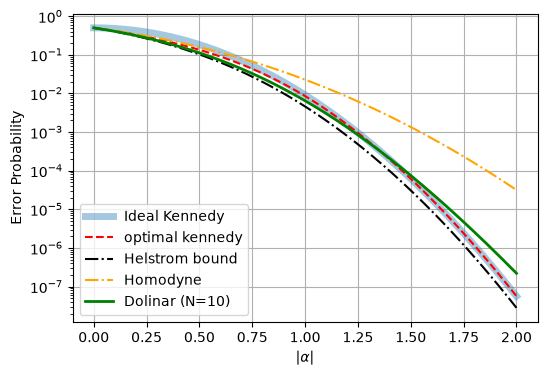

In [19]:
alphas=np.linspace(0,2,200)

# 2. Ideal Kennedy
P_kennedy = 0.5 * np.exp(-4 * np.abs(alphas)**2)

# 3. Helstrom bound
overlap_squared = np.exp(-4 * np.abs(alphas)**2)
P_helstrom = 0.5 * (1 - np.sqrt(1 - overlap_squared))

#optimal kennedy
P_kennedy_opt=[error_ke(N,i,beta_opt(i)) for i in alphas]

#homodyne
P_hom_theory = 0.5 * erfc(np.sqrt(2) * np.abs(alphas))

# --- Simplest Plot Structure ---
fig, ax = plt.subplots(figsize=(6, 4))

# 투명도(alpha=0.4)와 두께(linewidth=5)를 줘서 바탕에 깔아줌
ax.plot(alphas, P_kennedy, label="Ideal Kennedy", linewidth=5, alpha=0.4)

# 그 위에 얇은 점선('--')을 얹어서 두 그래프가 겹쳐서 같이 간다는 걸 증명
ax.plot(alphas,P_kennedy_opt , '--', label="optimal kennedy", color='red')

# 헬스트롬 바운드
ax.plot(alphas, P_helstrom, '-.', label="Helstrom bound", color='black')

#호모다인
ax.plot(alphas, P_hom_theory, '-.', label="Homodyne", color='orange')

#돌리너 리시버
P_dolinar = np.array([dolinar_error(al, 10) for al in alphas])
ax.plot(alphas, P_dolinar, label="Dolinar (N=10)", color='green', lw=2)

ax.set_yscale('log')   # 이거 없으면 세 곡선이 다 붙어 보임
ax.set_xlabel(r"$|\alpha|$")
ax.set_ylabel("Error Probability")
ax.grid(True)
ax.legend()

plt.show()